# Homework 4: Optional Advanced Final Project (A+ Grade Bump)

Incorporate README of nationality prediction model
Debug
Ensure reproducibility

- This homework template guides you through presenting your final project analysis. 
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/first-last/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Name-Inferred Inventor Origin and State-Level Patent Output
- **Student Name:** Lee Qi Cheng
- **Policy Relevance Statement:** Skilled-immigration policy (H-1B caps, visa restrictions) is frequently defended or opposed on the premise that foreign-born talent drives U.S. innovation. This project tests that premise directly by asking whether U.S. states with a larger name-inferred foreign-origin share of patent inventors actually produce more patents, once the size of each state's inventor pool is accounted for.
- **Central Hypothesis:** States with a higher share of foreign-origin-coded inventor names show higher patent output in 2025, controlling for the size of the state's inventor pool.
- **Scope:** Cross-sectional analysis of all 50 U.S. states plus DC, using patents granted in a single year (2025). This is not a panel or growth design. There is no year-over-year variation in the underlying data, so results describe a one-year snapshot, not a trend or a causal claim.
- **Datasets:** (1) USPTO annualized patent data (2025 grants, inventor-level), hosted on Hugging Face and pulled programmatically in Section 1. (2) A custom-trained name-to-nationality classifier (two single-layer GRU networks, one for first names and one for last names, 23 output categories), trained separately on a global first/last-name dataset and applied here to infer each inventor's likely name-coded origin.
- **Important caveat:** "Foreign-origin" here means *name-inferred* origin, that is a statistical guess based on how a name is spelled, not a measurement of citizenship, immigration status, or self-identified ethnicity. Many U.S.-born, multi-generation citizens would be coded as "foreign-origin" under this measure. Results should be read as describing name-coded patterns in patent records, not immigration status.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** USPTO Annualized Patent Data (2025 granted patents, inventor-level), hosted on a Hugging Face dataset repo and downloaded programmatically via `huggingface_hub.hf_hub_download`.
- **Variables Retrieved:** `patent_number`, `grant_year`, `country`, `state`, `inventors` (team size), and up to 10 inventor slots per patent (`inventor_id1`-`inventor_id10`, `inventor_name1`-`inventor_name10`).
- **Local Storage Path:** `data/final_project/qicheng-lee/raw/annual_patents_raw.csv`

In [1]:
# Import and run your advanced OOP data acquisition script
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../../src/final_project/qicheng-lee/advanced').resolve()))
import data
data_fetcher = data.DataAcquisition()
df_raw = data_fetcher.run()
df_raw.head()


Data acquired and saved to data\final_project\qicheng-lee\raw\annual_patents_raw.csv with shape (343743, 62)


,patent_number,grant_year,application_number,application_year,d_inventor,d_assignee,d_location,d_application,d_cpc,d_ipc,...,inventor_name8,male_flag8,inventor_id9,inventor_name9,male_flag9,inventor_id10,inventor_name10,male_flag10,wipo_sector_title9,wipo_field_title9
0,11694774,2025,16598793,2019,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12185648,2025,16972991,2019,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,12185649,2025,17154409,2021,1,0,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12185650,2025,17162175,2021,1,1,1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12185651,2025,17560959,2021,1,0,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Filtering:** Restricted to U.S.-assigned patents (`country == "US"`) with a valid state code (50 states + DC; territories and military codes excluded).
- **Reshaping:** The 10 wide inventor slots per patent were reshaped into one row per patent-inventor pair, dropping empty slots.
- **Classification:** Each of the 244,957 unique inventors in the filtered data was classified exactly once (not once per patent) through the two trained GRU name-to-nationality models, which jointly predict one of 23 name-coded nationality categories per inventor. Classification took roughly 11 minutes.
- **Bucketing:** The 23 raw categories were collapsed into two analysis groups for the regression: (1) `domestic` (English-coded names); and (2) `foreign` (everything else, undifferentiated). No individual non-domestic nationality (e.g. Chinese, Indian) is broken out as its own regression variable. The full, uncollapsed 23-category breakdown was preserved separately for descriptive purposes only (see Figure 3).
- **Aggregation:** Collapsed to a state-level cross-section with patent counts, inventor counts, and the domestic/foreign split per state.
- **Known Data Limitation — Multi-State Patent Overlap:** The raw USPTO extract is not strictly one row per patent: a patent whose inventors reside in more than one state is split across multiple state-tagged rows for that same patent. `patent_count` is computed as `nunique(patent_number)` *within* each state group, without first deduplicating patents nationally, so a patent with inventors in 2+ states is counted once in each of those states' totals. Verified directly against the underlying data: of the 135,585 distinct US patents with a valid-state inventor, **1,118 patents (~0.8%) have inventors split across 2+ states**, which inflates the sum of `patent_count` across all 51 states to 136,789 (~0.9% above the true national total). State-level `patent_count` should therefore be read as "patents with at least one inventor in this state," not as a strict partition of national patent output — the same patent can contribute to more than one state's count. The effect is small relative to Model 2's fit (R² = 0.988) but was not previously disclosed as a limitation of the aggregation step.
- **Final Dataset Observations:** 51 rows (50 states + DC) × 8 columns in the regression dataset (`state`, `patent_count`, `inventor_count`, `domestic`, `foreign`, `share_foreign`, `log_patents`, `log_inventor_count`); 23 rows × 4 columns in the separate descriptive nationality breakdown.
- **Clean Data Paths:** `data/final_project/qicheng-lee/clean/state_cross_section.csv` (regression data) and `data/final_project/qicheng-lee/clean/nationality_breakdown.csv` (descriptive breakdown).

### **Name-to-Nationality Prediction**
Relevant files and notebooks can be found in notebooks\hw\final_project\qicheng-lee

- **References:**
    - [Name Dataset](https://github.com/philipperemy/name-dataset) — source of the ~4.7 million first/last name records across 105 countries
    - [name2nat](https://github.com/Kyubyong/name2nat) — prior work on name-to-nationality prediction
    - [PyTorch RNN/LSTM/GRU notebook](https://www.kaggle.com/code/sharanharsoor/pytorch-rnn-lstm-gru) — basis for the model architecture
- **Data:** The dataset contains ~4.7 million names drawn from 105 countries. Because many countries share naming conventions, the 105 countries are consolidated into **23 nationality groups** organized by how distinctive their naming patterns are.
- **Nationality Grouping:**

    ### Tier 1 — Highly distinctive names

    These nationalities have naming patterns unique enough that they rarely get confused with others.

    | Group | Example patterns |
    |---|---|
    | Japanese (JP) | Syllabic CV patterns: -mura, -moto, -kawa (Tanaka, Suzuki) |
    | Korean (KR) | Very short, limited surname set (Kim, Park, Choi) |
    | Chinese (CN) | Short, distinctive romanizations (Wang, Li, Zhang) |
    | Finnish (FI) | Double vowels, -nen endings (Virtanen, Korhonen) |
    | Georgian (GE) | -shvili, -dze, -ia suffixes (Beridze, Kvirikashvili) |
    | Greek (GR) | -opoulos, -idis, -akis (Papadopoulos, Nikolaidis) |
    | Hungarian (HU) | sz, gy, cs clusters (Kovacs, Szabo, Nagy) |
    | Icelandic (IS) | Patronymic -son/-dottir, unique first names |

    ### Tier 2 — Distinctive with minor overlap

    Still recognizable, but occasional confusion with neighboring traditions.

    | Group | Example patterns |
    |---|---|
    | Polish (PL) | -ski, -wicz, -czyk, sz/cz clusters |
    | Italian (IT) | Vowel-heavy, -ini, -elli, -ucci |
    | French (FR) | Le-, Du-, -eux, -eau |
    | Turkish (TR) | Vowel harmony patterns (includes Azerbaijan, Turkmenistan, Kazakhstan) |
    | Persian (IR) | -zadeh, -pour, -nejad (includes Afghanistan) |
    | Lithuanian (LT) | -auskas, -aitis, -unas |
    | Indian (IN) | Singh, Patel, Kumar, -krishnan, -murthy |
    | Nigerian (NG) | Yoruba/Igbo patterns like Okonkwo, Adeyemi (includes Ghana, Burkina Faso) |

    ### Tier 3 — Merged groups

    Countries that share a language or naming tradition are grouped under one label.

    | Group | Members |
    |---|---|
    | Spanish (ES) | Spain, Mexico, Colombia, Argentina, Peru, Chile, + 10 others |
    | Portuguese (PT) | Portugal, Brazil, Angola |
    | Arabic (SA) | Saudi Arabia, Egypt, Iraq, Syria, Jordan, Lebanon, + 13 others |
    | English (GB) | UK, US, Canada, Ireland, Jamaica |
    | Nordic (SE) | Sweden, Denmark, Norway |
    | Slavic (CZ) | Czechia, Croatia, Serbia, Slovenia, Bulgaria, Russia |
    | Germanic (GM) | Germany, Netherlands |

    24 countries whose names don't map cleanly to any single group (e.g., Belgium, Singapore, Philippines) are dropped. After filtering, ~3.7 million names remain, split 80/20 into training and test sets.
- **How the Model Works:** The model reads a name **one letter at a time**, building up an internal summary of what it has seen so far. After processing the last letter, it outputs a probability for each of the 23 nationalities. Think of it like a person scanning a name left to right — the ending "-ovich" might suggest Slavic, while "-moto" might suggest Japanese. The model learns these patterns automatically from millions of examples rather than from hand-written rules. Because some nationalities have far more examples than others (Arabic names outnumber Korean names ~100:1), the training process **upweights underrepresented groups** so the model doesn't simply learn to guess "Arabic" for everything.
- **Accuracy:**
    | Metric | Last Name Model | First Name Model |
    |---|---|---|
    | Top-1 accuracy (exact match) | **60%** | **50%** |
    | Top-2 accuracy (correct in top 2 guesses) | **73%** | **64%** |

    Last names are more predictive than first names — first names are more likely to cross cultural boundaries (e.g., "Maria" appears in Spanish, Italian, Portuguese, and other traditions).

- **Confidence Calibration:** The model's self-reported confidence aligns well with actual accuracy. When the last name model says it is 90% confident, it is correct ~86% of the time. When it says 30%, it is correct ~34% of the time. The confidence score is a reliable indicator of prediction quality.
- **Key Limitations:** 
    - **Shared naming traditions** across nationality groups (e.g., English vs. Germanic) cause confusion — the models work best for Tier 1 and Tier 2 names with distinctive patterns.
    - **First names travel across cultures** more than last names, which is why the first-name model is less accurate.
    - **Low-sample groups** like Korean (~8,000 examples vs. ~900,000 for Arabic) are harder to predict reliably despite upweighting.
    - The model predicts **cultural/linguistic origin of the name**, not necessarily the person's actual nationality or ethnicity.

In [2]:
import manipulate
manipulator = manipulate.DataManipulation()
df_clean = manipulator.run()
df_clean.head()

Classifying inventors: 100%|██████████| 244957/244957 [11:14<00:00, 363.29it/s]


Nationality breakdown saved to data\final_project\qicheng-lee\clean\nationality_breakdown.csv with shape (23, 4)
Data processed and saved to data\final_project\qicheng-lee\clean\state_cross_section.csv with shape (51, 8)


,state,patent_count,inventor_count,domestic,foreign,share_foreign,log_patents,log_inventor_count
0,AK,7,19,10,9,0.473684,1.945910,2.944439
1,AL,292,639,306,333,0.521127,5.676754,6.459904
2,AR,307,816,243,573,0.702206,5.726848,6.704414
3,AZ,1807,3057,1124,1933,0.632319,7.499423,8.025189
4,CA,43576,77691,20620,57071,0.734590,10.682262,11.260495


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** California and Washington have the highest name-inferred foreign-origin inventor shares (~73%), with most states clustering between roughly 45% and 65%. Some high-ranking states (e.g., ID, AR) aren't the usual tech hubs. This is likely a noisier estimate given how few inventors those states have in the sample (denominators as small as 19 in AK).
- **Figure 2 Key Takeaway:** The raw bivariate relationship looks positive, but this is driven by a state-size confound. California alone (77,691 inventors) is an extreme outlier pulling the fit upward. This figure is descriptive/pre-regression; once state size is controlled for in Section 4, the relationship is no longer statistically significant.
- **Figure 3 Key Takeaway:** The full 23-category breakdown surfaces a classifier reliability concern rather than a substantive finding: "Arabic" is predicted as the second-largest name-inferred category nationwide (~24%, behind only "English" at ~34%), while "Indian" is nearly the smallest category (~0.2-0.3%) despite Indian-origin inventors being one of the largest non-domestic groups in U.S. tech by independent measures (e.g., USCIS H-1B data). This suggests the classifier may be systematically misrouting South Asian names into the Arabic category, and tempers confidence in any Chinese/Indian-specific claims drawn from this data.


Figures saved to reports\final_project\qicheng-lee


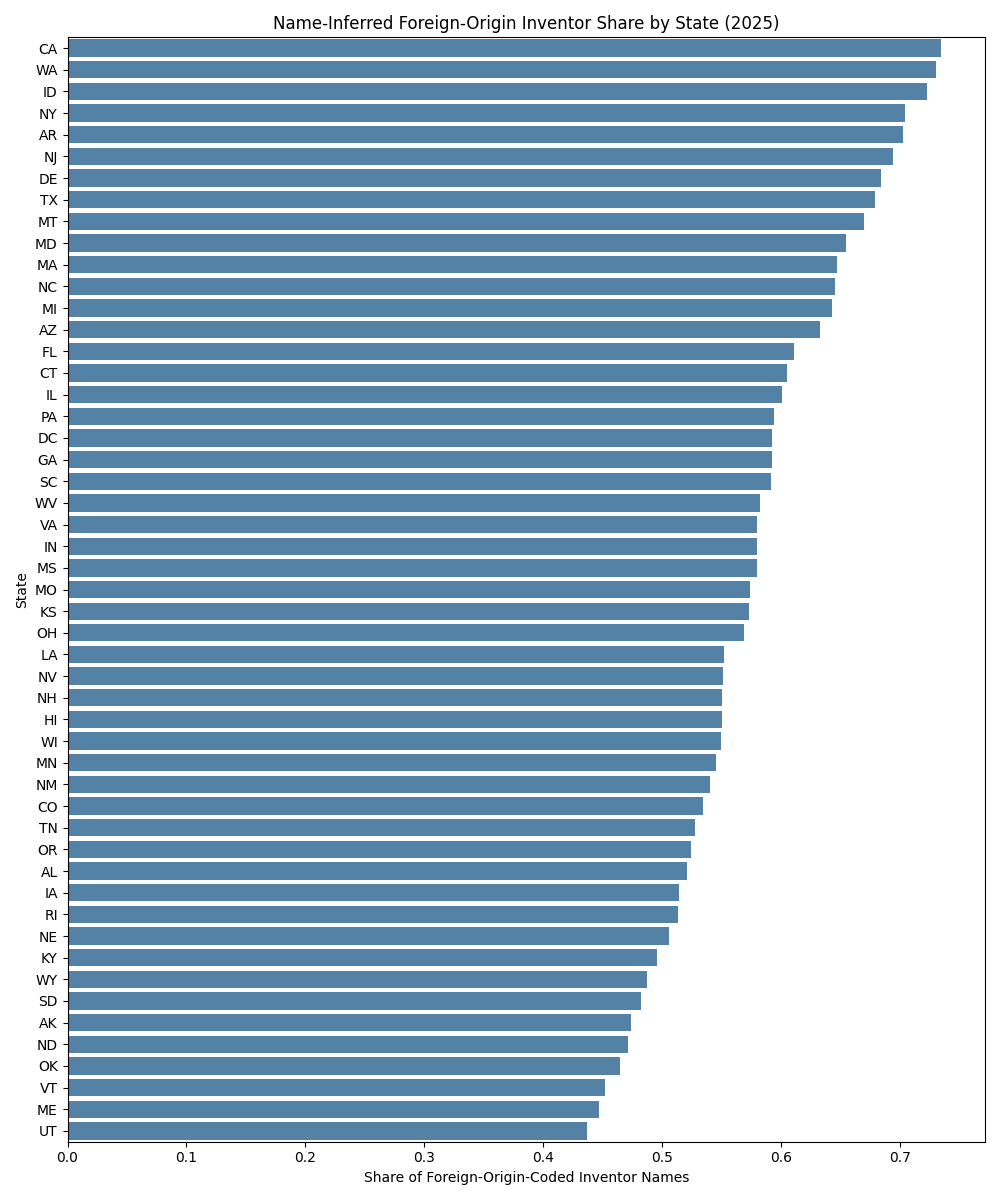

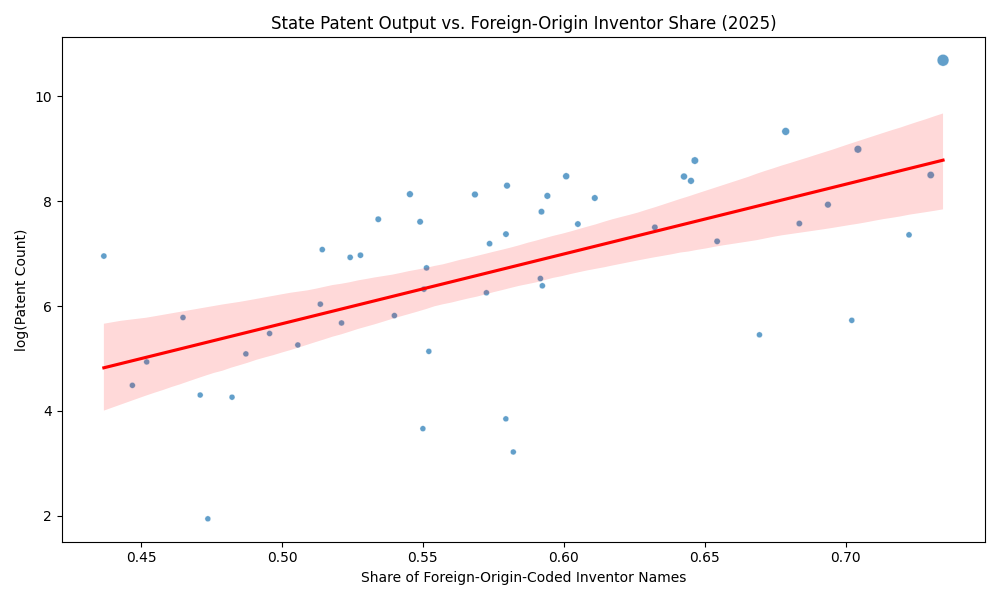

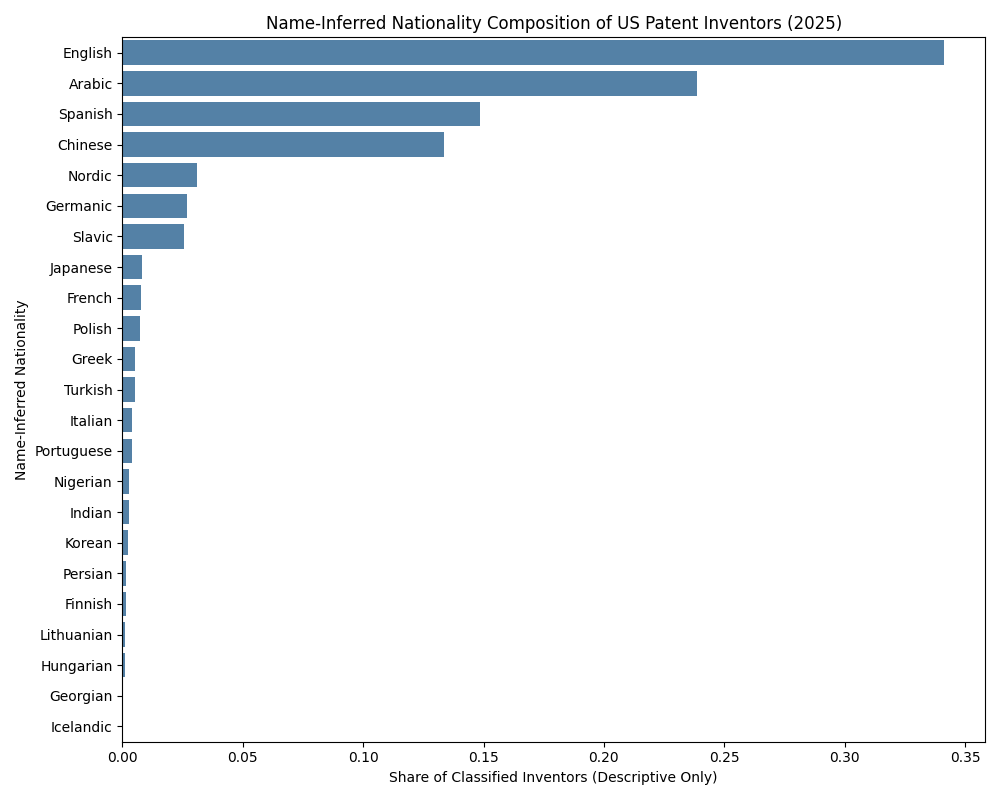

In [2]:
import graph
from IPython.display import Image, display

visualizer = graph.DataVisualization()
figs = visualizer.run()
for fig_path in figs:
    display(Image(filename=str(fig_path)))

## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** Cross-sectional Ordinary Least Squares (OLS) with heteroskedasticity-robust (HC1) standard errors, run as two specifications. A panel/fixed-effects model was not used because the data covers a single year (2025) with no year-over-year variation.
- **Dependent Variable (both models):** `log_patents` (log of state patent count)

**Model 1 — Bivariate, no control for state size:**
- **Independent Variable:** `share_foreign` only
- **Model Fit Metrics:** R-squared = 0.367, Adjusted R-squared = 0.354, N = 51
- **Coefficient of `share_foreign`:** 13.2834, Std. Err: 2.540, z: 5.230, p-value: <0.001 (95% CI: [8.31, 18.26])
- **Statistical Significance:** Strongly significant, and positive — consistent with the upward-sloping fit line visible in Figure 2.

**Model 2 — With inventor count control (primary specification):**
- **Independent Variables:** `share_foreign`, `log_inventor_count` (control for the size of each state's inventor pool)
- **Model Fit Metrics:** R-squared = 0.988, Adjusted R-squared = 0.987, N = 51
- **Coefficient of `share_foreign`:** -0.3554, Std. Err: 0.645, z: -0.551, p-value: 0.582 (95% CI: [-1.62, 0.91])
- **Coefficient of `log_inventor_count`:** 1.0306, Std. Err: 0.021, z: 48.895, p-value: <0.001
- **Statistical Significance:** `share_foreign` is no longer significant (p = 0.582), and its point estimate flips to the opposite sign from Model 1. `log_inventor_count` is highly significant and accounts for nearly all of the explained variance.

- **Key Conclusion:**
    - Comparing the two models makes the confounding explicit rather than just implied by Figure 2. Model 1, taken alone, would suggest a strong positive relationship between foreign-origin share and patent output. However, that relationship disappears entirely once state size is controlled for in Model 2, meaning it was very likely driven by the fact that larger states (more inventors) happen to also have higher foreign-origin shares, not by a genuine link between origin composition and innovation output
    - Taking Model 2 as the primary specification, **the central hypothesis is not supported**: after accounting for the size of a state's inventor pool, there is no statistically significant relationship between name-inferred foreign-origin share and patent output. 
    - Four limitations temper this null result rather than making it the final word: (1) the classifier reliability concern raised in Figure 3 casts doubt on what "foreign-origin" is actually capturing here; (2) with only 51 observations and one extreme outlier (California), the significant right-skew and non-normal residuals in Model 2 (Jarque-Bera p < 0.001) suggest the result may be sensitive to that single point — a California-excluded robustness check would be a natural next step; (3) this is a single-year cross-section, so the result speaks to a 2025 snapshot only, not a growth or causal claim about immigration policy's effect on innovation over time; (4) `patent_count` (and therefore `log_patents`) has a small multi-state-overlap inflation — about 0.9% of the national total, from the ~1,118 patents whose inventors span more than one state and are counted once per state (see Section 2 preprocessing note) — which is unlikely to change the null result given Model 2's R² = 0.988, but means the dependent variable is not a strict partition of national patent output.

In [2]:
import model
modeler = model.EconometricModeling()
results = modeler.run()

print("=== Model 1: Without Inventor Count Control ===")
print(results["bivariate"].summary())

=== Model 1: Without Inventor Count Control ===
                            OLS Regression Results                            
Dep. Variable:            log_patents   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     27.35
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.50e-06
Time:                        12:14:00   Log-Likelihood:                -88.197
No. Observations:                  51   AIC:                             180.4
Df Residuals:                      49   BIC:                             184.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [3]:
print("=== Model 2: With Inventor Count Control (Primary Specification) ===")
print(results["controlled"].summary())

=== Model 2: With Inventor Count Control (Primary Specification) ===
                            OLS Regression Results                            
Dep. Variable:            log_patents   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     2722.
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.96e-50
Time:                        12:14:00   Log-Likelihood:                 12.800
No. Observations:                  51   AIC:                            -19.60
Df Residuals:                      48   BIC:                            -13.80
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------